# Part A: Initial Data Exploration

In [3]:
#Load a dataset and display it
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

airbnb = pd.read_csv("listings.csv")

airbnb.head()

C:\Users\S553902\AppData\Local\Temp\ipykernel_31284\1556765603.py:6: DtypeWarning: Columns (0: host_since) have mixed types. Specify dtype option on import or set low_memory=False.
  airbnb = pd.read_csv("listings.csv")


,id,name,host_id,host_name,host_since,host_response_time,host_response_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,...,bathrooms,bedrooms,beds,price,minimum_nights,availability_365,number_of_reviews,review_scores_rating,license,instant_bookable
0,670339032744709144,Westwood lovely three bedrooms three bathrooms,4780152,Moon,20/01/13,within a few hours,0.96,f,West Los Angeles,City of Los Angeles,...,3.0,3.0,3.0,399.0,30,365,0,NaN,NaN,f
1,37014494,Spanish style lower duplex near Beverly Hills,278288178,Ida,22/07/19,NaN,NaN,f,Beverlywood,City of Los Angeles,...,NaN,2.0,NaN,NaN,30,0,0,NaN,NaN,f
2,1024835174766068422,Charming Beverly Hills Home,513813179,Tiana,08/05/23,within a day,0.60,f,Beverly Hills,Other Cities,...,3.0,3.0,3.0,434.0,30,267,0,NaN,NaN,f
3,850744632375448560,Tianpu's warm room with bathroom,432956623,Dan,22/11/21,a few days or more,0.20,f,Temple City,Other Cities,...,1.0,1.0,1.0,49.0,1,364,1,3.00,NaN,f
4,953950676345326970,"Santa Monica apt, free parking, steps to the b...",528669205,Farkhat,29/07/23,within an hour,1.00,t,Santa Monica,Other Cities,...,1.0,0.0,1.0,231.0,5,193,44,4.93,Exempt,t


**Describe the dataset and note any interesting relationships between features.**

This dataset contains Airbnb listing located in Los Angeles. Each row represents a listing and includes property characteristics, location data, and review information.

Important features include:
* price: nightly listing price (target variable)
* bedrooms and bathrooms: property size indicators
* property_type and room_type: listing category
* latitude and longitude: geographic location
* number_of_reviews and review_scores_rating: guest feedback
* availability_365: number of available days per year

These features capture both the physical characteristics of the property and its popularity among guests.

**Identify the feature(s) you would like to predict and explain why.**

The feature that will be predicted in this project is price. Price was selected as the target variable because the goal of the project is to determine whether listing characteristics and environmental factors can be used to estimate Airbnb prices. Since price is a continuous numeric value, a linear regression model is appropriate for predicting it. Potential predictor variables include bedrooms, bathrooms, number of reviews, and review scores because these features may influence how hosts set their listing prices.

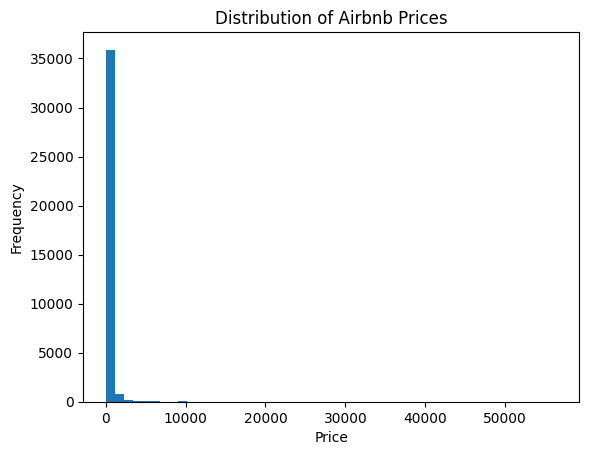

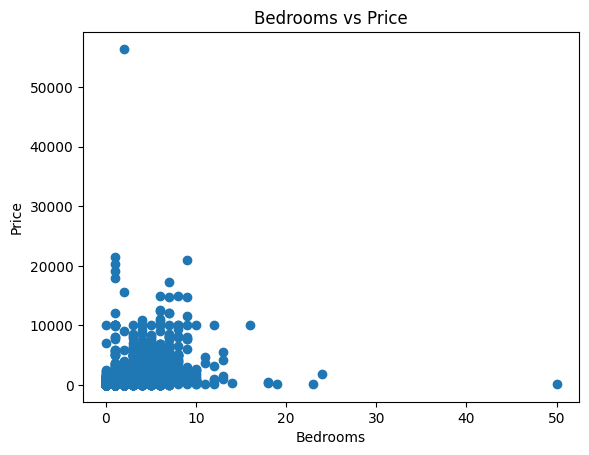

                      price  bedrooms  bathrooms  number_of_reviews  \
price              1.000000  0.377762   0.465234          -0.062776   
bedrooms           0.377762  1.000000   0.767262          -0.104285   
bathrooms          0.465234  0.767262   1.000000          -0.104318   
number_of_reviews -0.062776 -0.104285  -0.104318           1.000000   
availability_365   0.042942  0.047399   0.061597          -0.104021   

                   availability_365  
price                      0.042942  
bedrooms                   0.047399  
bathrooms                  0.061597  
number_of_reviews         -0.104021  
availability_365           1.000000  


id                                  0
name                                0
host_id                             0
host_name                           0
host_since                          0
host_response_time               4256
host_response_rate               4256
host_is_superhost                1154
neighbourhood_cleansed              0
neighbourhood_group_cleansed        0
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bathrooms                           0
bedrooms                            0
beds                              106
price                               0
minimum_nights                      0
availability_365                    0
number_of_reviews                   0
review_scores_rating                0
license                         25793
instant_bookable                    0
dtype: int64

In [14]:
#Clean the dataset (handle missing values, duplicates, etc.)
airbnb['price'] = airbnb['price'].replace(r'[\$,]', '', regex=True).astype(float)

plt.hist(airbnb['price'], bins=50)
plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

plt.scatter(airbnb['bedrooms'], airbnb['price'])
plt.title("Bedrooms vs Price")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

corr = airbnb[['price', 'bedrooms', 'bathrooms', 'number_of_reviews', 'availability_365']].corr()
print(corr)

airbnb = airbnb.drop_duplicates()
airbnb = airbnb.dropna(subset=['price', 'bedrooms', 'bathrooms'])
airbnb['review_scores_rating'] = airbnb['review_scores_rating'].fillna(airbnb['review_scores_rating'].mean())
airbnb.isnull().sum()

In [15]:
#Create training and testing datasets
from sklearn.model_selection import train_test_split

X = airbnb[['bedrooms', 'bathrooms', 'number_of_reviews', 'availability_365']]

y = airbnb['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training dataset shape:", X_train.shape)
print("Testing dataset shape:", X_test.shape)

Training dataset shape: (29712, 4)
Testing dataset shape: (7428, 4)


# Part B: Linear Regression Modeling

In [16]:
#Perform initial data preparation (read, clean, split)
X = airbnb[['bedrooms', 'bathrooms', 'number_of_reviews', 'availability_365']]

y = airbnb['price']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (37140, 4)
Target shape: (37140,)


**Select features for X and the target variable y, with justification.**

For the regression model, the following variables were selected as predictor features (X):
* bedrooms
* bathrooms
* number_of_reviews
* availability_365

These features were chosen because they represetn important characteristics of Airbnb listings. Larger properties with more bedrooms and bathrooms often command higher prices. The number of reviews may indicate popularity, while availability may reflect demand for the listing.

The target variable (y) is price, which represents the nightly rental cost of an Airbnb listing.

In [18]:
#Train a linear regression model and compute evaluation metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_train)

mse = mean_squared_error(y_train, y_pred)
mae = mean_absolute_error(y_train, y_pred)
r2 = r2_score(y_train, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

print("Model Coefficients:", model.coef_)

Mean Squared Error: 400397.2124823977
Mean Absolute Error: 176.03372825449705
R2 Score: 0.2007349706462055
Model Coefficients: [ 2.91048207e+01  2.35004689e+02 -9.72567026e-02  9.34399042e-02]


**Interpret and comment on the results**

The results show that the model is able to capture some relationship between the selected features and Airbnb listing prices, but the overall predictive power is limited.

The R2 score of 0.20 indicates that the model explains roughly 20% of the variation in listing prices. This suggests that the features used in the model influence price, but many other important factors are not included.

Looking at the coefficients, bathrooms have the largest impact on price, with each additional bathroom increasing the predicted price by about `$235`. Bedrooms also increase price, but by a smaller amount of about `$29` per additional bedroom. The number of reviews has a very small negative relationship with price, meaning listings with more reviews may be slightly cheaper on average. Availability has only a very small positive effect on predicted price.

Overall, the model suggests that property size features like bedrooms and bathrooms contribute to higher Airbnb prices, but the relatively low R2 value indicates that other variables like location, amenities, or neighborhood characteristics likely play a significant role in determining listing prices.

In [19]:
#Attempt to improve model performance
X = airbnb[['bedrooms', 'bathrooms', 'number_of_reviews', 'availability_365', 'review_scores_rating', 'latitude', 'longitude']]
y = airbnb['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (29712, 7)
Testing shape: (7428, 7)


In [20]:
#Peform final evaluation using the test dataset
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 397742.82660808536
Mean Absolute Error: 189.59882230354762
R2 Score: 0.28607974161689065


**Analyze model parameters and summarize insights gained.**

The model produced a Mean Squared Error of approximately 397,743 and a Mean Absolute Error of about `$189.60`, meaning that on average the model's predicted price differs from the actual listing price by roughly `$190 per night`.

The R2 score of approximately 0.29 indicates that the model explains about 28.6% of the variation in Airbnb listing prices. Compared to the earlier model, this represents a slight improvement in predictive performance after adding an additional feature.

These results suggest that the featurs used in the model do have some influence on Airbnb pricing, particularly property characteristics like bedrooms and bathrooms. However, the R2 value also shows that a large portion of price variation is still unexplained by the current model.

This indicates that additional variables like location, amenities, neighborhood characteristics, or external factors like crime rates may play an important role in determining Airbnb prices and could further improve model performance in future analysis.

# Part C: Project Overview and Insights

**Overview of Part A findings**

The dataset used in this project contains Airbnb listings located in Los Angeles. Each observation represents a listing and includes property characteristics, geographic information, and review data. Important variables in the dataset include price, bedrooms, bathrooms, latitude, longitude, number of reviews, review scores, and availability throughout the year.

The target variable selected for prediction was price, which represents the nightly rental cost of an Airbnb listing. Price was chosen because the goal of the project is to determine whether listing characteristics and environmental factors can be used to estimate Airbnb prices. Since price is a continuous numeric variable, linear regression is an appropriate modeling approach.

Initial exploration of the dataset showed some relationships between property features and price. The correlation table indicated moderate positive relationships between price and bedrooms (0.38) and price and bathrooms (0.47). This suggests that larger properties generally charge higher nightly rates. Other features such as number of reviews and availability showed very weak relationships with price, indicating they may have less influence on pricing compared to property size.

**Summary of Part B modeling results**

A linear regression model was developed to predict Airbnb listing prices using several property features. The initial model used four predictor variables: bedrooms, bathrooms, number of reviews, and availability.

The first model produced an R² score of approximately 0.20, meaning that the model explained about 20% of the variation in listing prices. The results also showed that bathrooms had the largest positive impact on predicted price, increasing the estimated nightly price by about `$235` for each additional bathroom. Bedrooms also increased predicted price, but by a smaller amount of about `$29` per additional bedroom.

To improve the model, an additional feature was included and the model was retrained. After this change, the final model produced an R² score of approximately 0.29, indicating that the model explained about 28.6% of the variation in listing prices. Although the improvement was modest, it showed that adding additional relevant features can help increase predictive performance.

Overall, the regression model captured some relationship between property characteristics and Airbnb prices, but it also demonstrated that many other factors likely influence pricing.

**Final insights, challenges faces, and lessons learned from the project.**

This project demonstrated how machine learning techniques such as linear regression can be used to analyze and predict Airbnb listing prices. The results showed that property size features, particularly the number of bedrooms and bathrooms, play an important role in determining listing prices. However, the relatively low R² values indicate that these variables alone cannot fully explain price variation.

One of the main insights from this project is that Airbnb pricing is influenced by many different factors beyond basic property characteristics. Variables like location, amenities, neighborhood demand, and environmental conditions may significantly affect listing prices. In future work, incorporating additional features such as neighborhood crime rates or geographic information could potentially improve the model’s predictive accuracy.

A challenge encountered during this project was preparing the dataset for modeling, including cleaning missing values and selecting appropriate features. This process highlighted the importance of data preprocessing in machine learning workflows.

Overall, this project provided valuable experience in exploring datasets, preparing data for analysis, building regression models, and evaluating model performance.